### ============================================================
### NB5 — XAI Interpretation and PubChemFP Mapping
### ============================================================
### Author: Hamid Bouseber
### Project: COX-2 QSAR-XAI workflow
### Inputs:
### - PubChem descriptor matrices generated in NB2
### - Optimized QSAR model configuration from NB3/NB4
### - PubChemFP definition mapping file
### Outputs:
### - Figure 5: Permutation importance
### - Figure 6: SHAP beeswarm plot
### - Table 4: XAI PubChemFP mapping
### - CSV files containing SHAP and permutation importance results

# NB5 — XAI Interpretation and PubChemFP Mapping

Final model: **PubChem fingerprints + Random Forest**

This notebook produces publication-ready XAI outputs:

- **Figure 5** — Permutation importance of the top PubChemFP features
- **Figure 6** — SHAP beeswarm plot for global model interpretation
- **Table 4** — Mapping of top PubChemFP features to chemical definitions

The notebook keeps the **Top 10 features**, consistent with manuscript-level interpretation.


## 1. Imports and configuration

In [1]:

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import shap

In [2]:

# ----------------------------
# Paths
# ----------------------------
MATRICES_DIR = "./matrices"
RESULTS_DIR = "./results"
FIGURES_DIR = "./figures"

# Put PubChemFP mapping CSV in one of these folders if available
MAPPING_DIRS = "./definitions"

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

FONT_DIR = "./fonts"

# ----------------------------
# Model settings
# ----------------------------
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_ESTIMATORS = 300

# ----------------------------
# XAI settings
# ----------------------------
TOP_N = 10
N_REPEATS = 10
SHAP_SAMPLE_SIZE = 500

# ----------------------------
# Figure settings
# ----------------------------
DPI = 300
FONT_SIZE = 8
FIG_FORMATS = ["png", "tiff"]


## 2. Figure style

In [3]:

if os.path.exists(FONT_DIR):
    for file in os.listdir(FONT_DIR):
        if file.lower().endswith((".ttf", ".otf")):
            font_manager.fontManager.addfont(os.path.join(FONT_DIR, file))

plt.rcParams.update({
    "font.family": "Arial",
    "font.size": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE,
    "figure.titlesize": FONT_SIZE,
    "axes.linewidth": 0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
})

def style_axes(ax):
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_linewidth(0.8)
    ax.tick_params(width=0.8, length=3)

def save_figure(fig, name):
    for fmt in FIG_FORMATS:
        path = os.path.join(FIGURES_DIR, f"{name}.{fmt}")
        if fmt == "tif":
            fig.savefig(
                path,
                dpi=DPI,
                bbox_inches="tight",
                format="tiff",
                pil_kwargs={"compression": "tiff_lzw"}
            )
        else:
            fig.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"Saved figure: {name}")


## 3. Helper functions

In [4]:

def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

def make_rf():
    return RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )

def extract_pubchem_bit(feature_name):
    match = re.search(r"PubchemFP(\d+)", str(feature_name))
    return int(match.group(1)) if match else np.nan


## 4. Load PubChem descriptor matrices

In [5]:

X = pd.read_csv(f"{MATRICES_DIR}/X_pubchem_train_test.csv")
y = pd.read_csv(f"{MATRICES_DIR}/y_train_test.csv").iloc[:, 0].astype(float)

X_external = pd.read_csv(f"{MATRICES_DIR}/X_pubchem_external.csv")
y_external = pd.read_csv(f"{MATRICES_DIR}/y_external.csv").iloc[:, 0].astype(float)

assert list(X.columns) == list(X_external.columns), "Train/external PubChem columns are not aligned."

print("Train/test matrix:", X.shape)
print("External matrix:", X_external.shape)


Train/test matrix: (2297, 481)
External matrix: (58, 481)


## 5. Train final model and internal model

In [6]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True
)

# Internal model for permutation importance
model_internal = make_rf()
model_internal.fit(X_train, y_train)
pred_test = model_internal.predict(X_test)

# Final model for SHAP interpretation
model_final = make_rf()
model_final.fit(X, y)
pred_external = model_final.predict(X_external)

model_summary = pd.DataFrame([
    {"Dataset": "Internal test", **regression_metrics(y_test, pred_test), "n": len(y_test)},
    {"Dataset": "External", **regression_metrics(y_external, pred_external), "n": len(y_external)}
]).round(3)

model_summary.to_csv(f"{RESULTS_DIR}/NB5_xai_model_summary.csv", index=False)
model_summary


,Dataset,R2,RMSE,MAE,n
0,Internal test,0.652,0.754,0.528,460
1,External,0.470,0.433,0.368,58


## 6. Permutation importance

In [7]:

perm = permutation_importance(
    model_internal,
    X_test,
    y_test,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
    scoring="r2",
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "feature": X.columns,
    "pubchem_bit": [extract_pubchem_bit(c) for c in X.columns],
    "permutation_importance_mean": perm.importances_mean,
    "permutation_importance_std": perm.importances_std
}).sort_values("permutation_importance_mean", ascending=False).reset_index(drop=True)

perm_importance.to_csv(f"{RESULTS_DIR}/NB5_permutation_importance_all.csv", index=False)

perm_top = perm_importance.head(TOP_N).copy()
perm_top.round(5)


,feature,pubchem_bit,permutation_importance_mean,permutation_importance_std
0,PubchemFP385,385,0.18207,0.03203
1,PubchemFP712,712,0.04521,0.00984
2,PubchemFP192,192,0.03795,0.00656
3,PubchemFP561,561,0.03212,0.01218
4,PubchemFP147,147,0.02461,0.01062
5,PubchemFP422,422,0.02445,0.00561
6,PubchemFP688,688,0.02414,0.00685
7,PubchemFP193,193,0.02363,0.00351
8,PubchemFP299,299,0.02112,0.00273
9,PubchemFP399,399,0.01983,0.00162


## 7. Figure 5 — Permutation importance

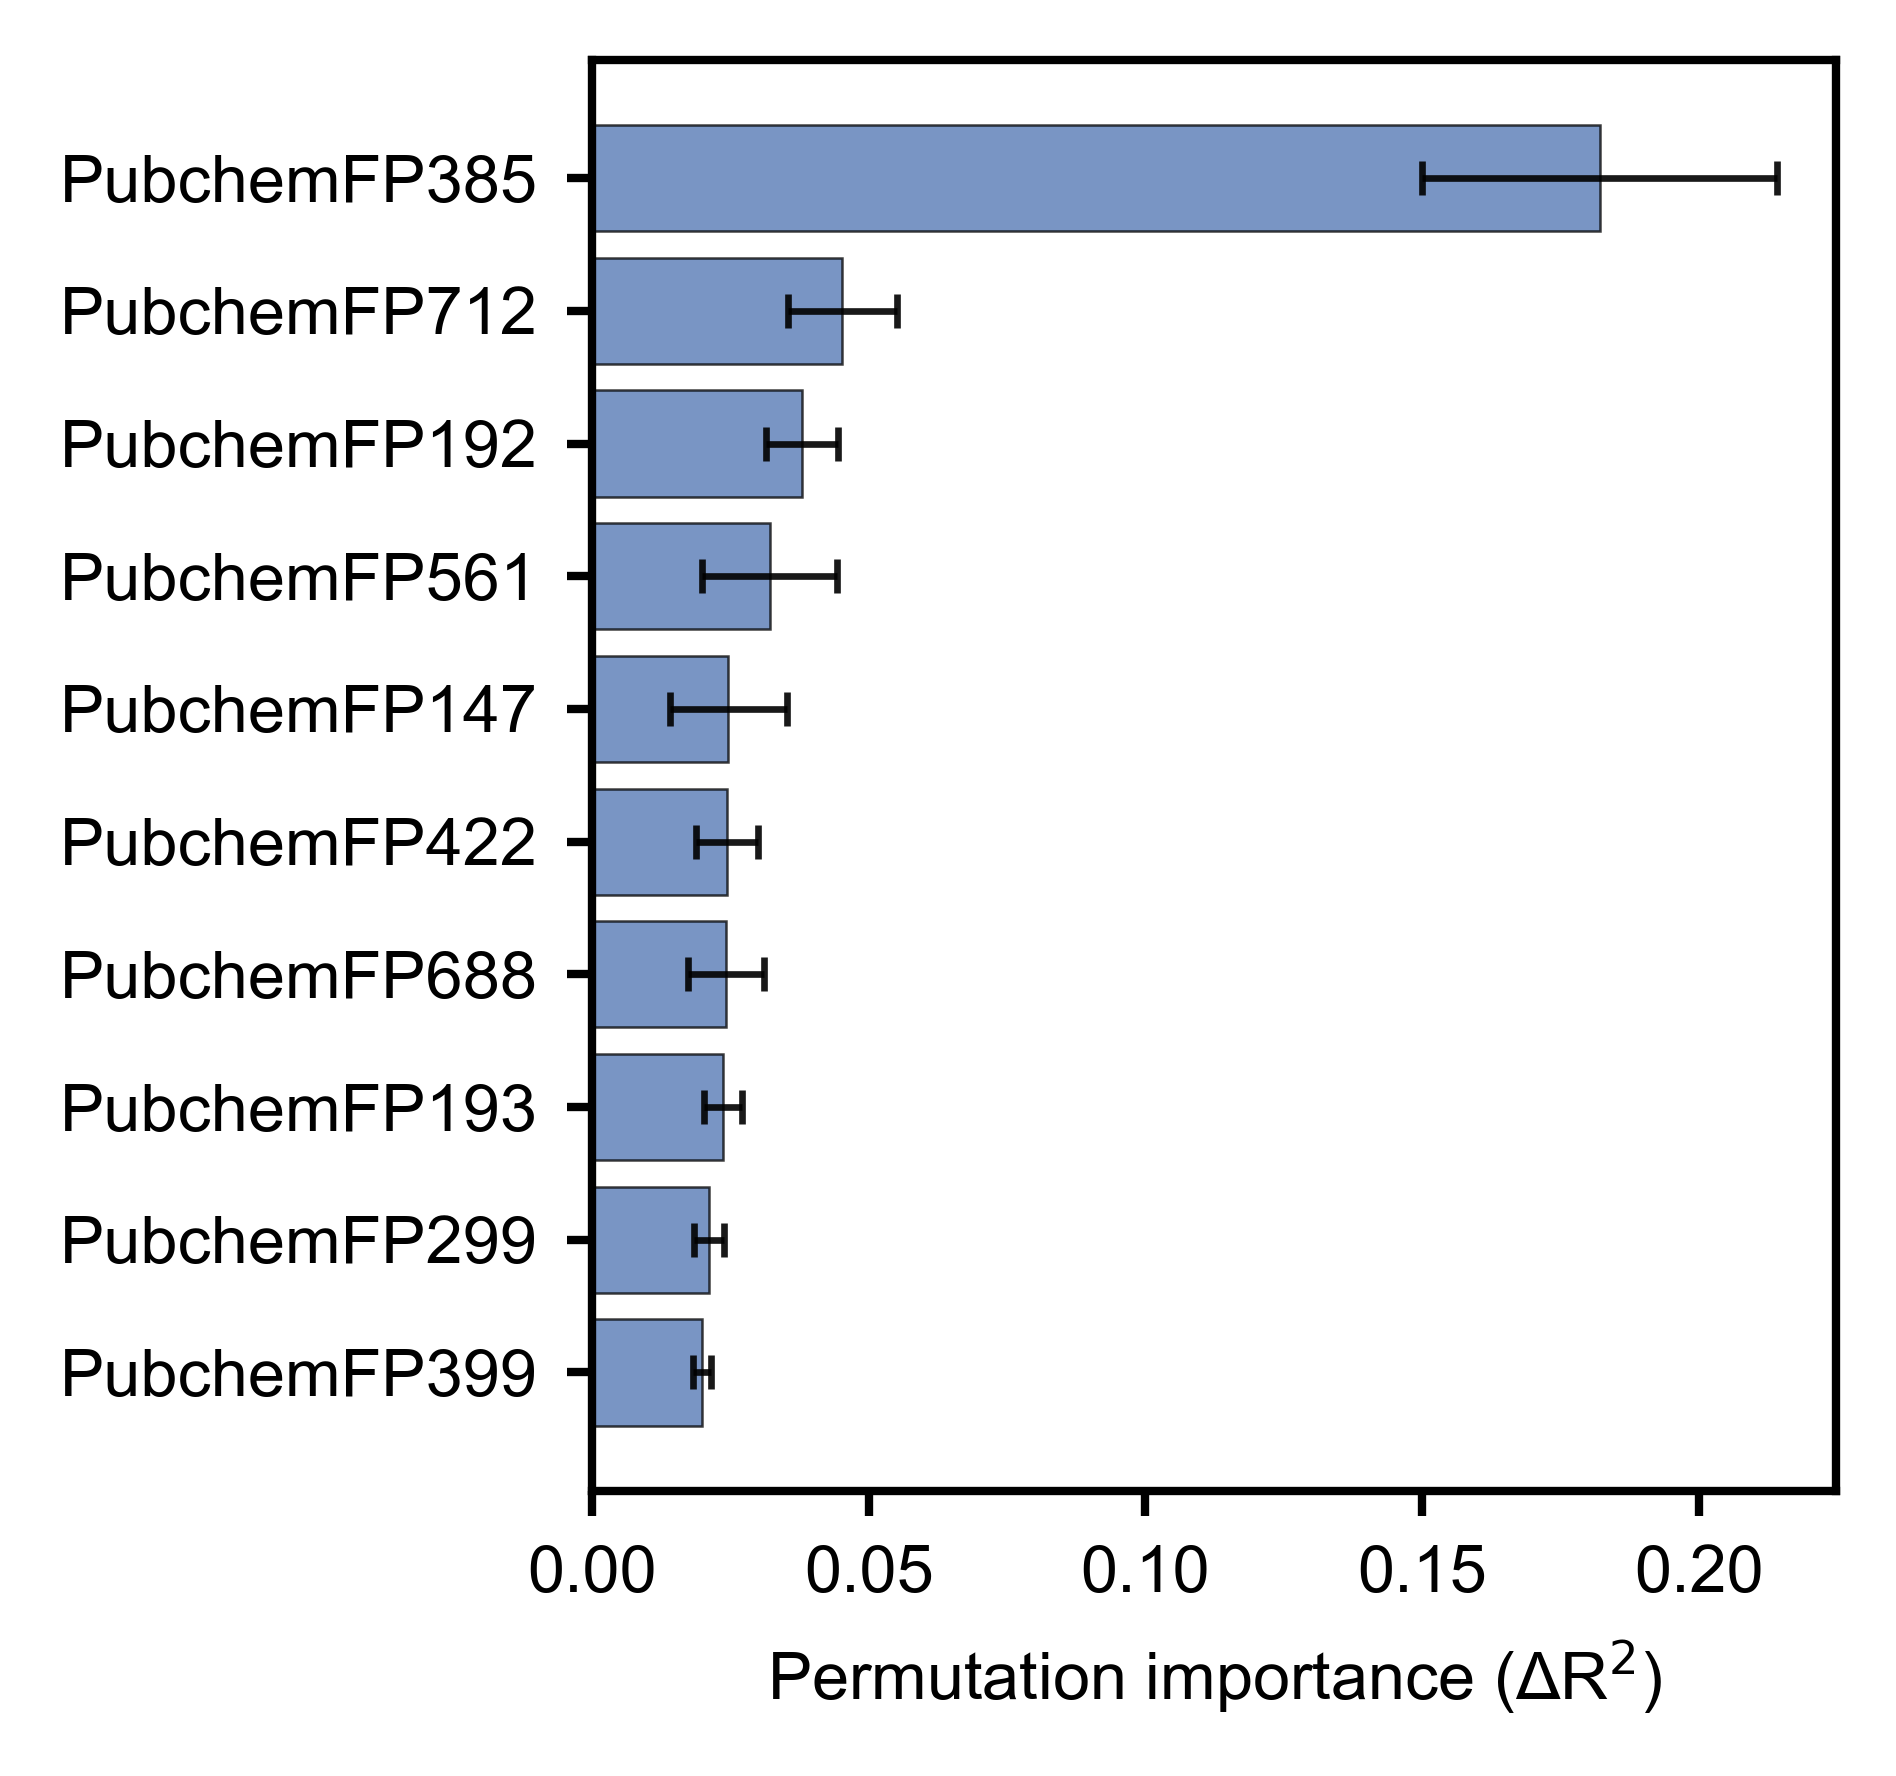

Saved:
./figures/Figure5_Permutation_Importance.png
./figures/Figure5_Permutation_Importance.tiff


In [8]:
# ============================================================
# Figure — Permutation Importance
# PNG + TIFF, journal-ready
# ============================================================

import os
import matplotlib.pyplot as plt

plot_df = perm_top.iloc[::-1].copy()

fig, ax = plt.subplots(
    figsize=(3.2, 3.0),
    dpi=600,
    facecolor="white"
)

ax.barh(
    plot_df["feature"],
    plot_df["permutation_importance_mean"],
    xerr=plot_df["permutation_importance_std"],
    color="#4C72B0",
    alpha=0.75,
    edgecolor="black",
    linewidth=0.30,
    capsize=2,
    error_kw={
        "elinewidth": 0.8,
        "capthick": 0.8,
        "alpha": 0.9
    }
)

ax.set_xlabel("Permutation importance (ΔR$^2$)", fontsize=8)
ax.set_ylabel("")

ax.tick_params(axis="both", labelsize=8, width=1.0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)

ax.grid(False)

plt.tight_layout()

out_png = os.path.join(FIGURES_DIR, "Figure5_Permutation_Importance.png")
out_tiff = os.path.join(FIGURES_DIR, "Figure5_Permutation_Importance.tiff")

fig.savefig(out_png, dpi=600, bbox_inches="tight", facecolor="white")
fig.savefig(
    out_tiff,
    dpi=600,
    bbox_inches="tight",
    facecolor="white",
    format="tiff",
    pil_kwargs={"compression": "tiff_lzw"}
)

plt.show()

print("Saved:")
print(out_png)
print(out_tiff)

## 8. SHAP analysis

In [ ]:

if len(X) > SHAP_SAMPLE_SIZE:
    X_shap = X.sample(n=SHAP_SAMPLE_SIZE, random_state=RANDOM_STATE)
else:
    X_shap = X.copy()

explainer = shap.TreeExplainer(model_final)
shap_values = np.array(explainer.shap_values(X_shap))

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "pubchem_bit": [extract_pubchem_bit(c) for c in X_shap.columns],
    "mean_abs_SHAP": mean_abs_shap
}).sort_values("mean_abs_SHAP", ascending=False).reset_index(drop=True)

shap_importance.to_csv(f"{RESULTS_DIR}/NB5_shap_importance_all.csv", index=False)

shap_top = shap_importance.head(TOP_N).copy()
shap_top.round(5)


## 9. Figure 6 — SHAP beeswarm

In [ ]:
# ============================================================
# Figure — SHAP Beeswarm
# PNG + TIFF, journal-ready
# ============================================================

import os
import matplotlib.pyplot as plt

plt.figure(
    figsize=(4.2, 3.2),
    dpi=600,
    facecolor="white"
)

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=TOP_N,
    show=False,
    plot_size=None
)

fig = plt.gcf()
ax = plt.gca()

ax.set_xlabel("SHAP value", fontsize=8)

ax.tick_params(axis="both", labelsize=8, width=1.0)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)

ax.grid(False)

# Harmonize colorbar if present
for current_ax in fig.axes:
    current_ax.tick_params(labelsize=8, width=1.0)
    current_ax.xaxis.label.set_size(8)
    current_ax.yaxis.label.set_size(8)

    for spine in current_ax.spines.values():
        spine.set_linewidth(1.0)

out_png = os.path.join(FIGURES_DIR, "Figure6_SHAP_Beeswarm.png")
out_tiff = os.path.join(FIGURES_DIR, "Figure6_SHAP_Beeswarm.tiff")

fig.savefig(out_png, dpi=600, facecolor="white")
fig.savefig(
    out_tiff,
    dpi=600,
    facecolor="white",
    format="tiff",
    pil_kwargs={"compression": "tiff_lzw"}
)

plt.show()

print("Saved:")
print(out_png)
print(out_tiff)

## 10. Load PubChemFP mapping file

In [ ]:
# ============================================================
# Table 4 — XAI top features with PubChemFP mapping from CSV
# ============================================================

import re

DEFINITIONS_CSV = "./definitions/pubchemfp_definitions.csv"
TOP_N_MAPPING = 10

if not os.path.exists(DEFINITIONS_CSV):
    raise FileNotFoundError(f"Missing mapping CSV: {DEFINITIONS_CSV}")

def extract_pubchem_bit(feature_name):
    match = re.search(r"PubchemFP(\d+)", str(feature_name))
    return int(match.group(1)) if match else None

# Load official PubChemFP definitions
pubchem_mapping = pd.read_csv(DEFINITIONS_CSV)

required_cols = {"bit", "definition"}
missing_cols = required_cols - set(pubchem_mapping.columns)

if missing_cols:
    raise ValueError(
        f"Mapping CSV must contain columns {required_cols}. "
        f"Missing: {missing_cols}"
    )

pubchem_mapping = pubchem_mapping[["bit", "definition"]].copy()
pubchem_mapping = pubchem_mapping.rename(columns={"bit": "pubchem_bit"})
pubchem_mapping["pubchem_bit"] = pubchem_mapping["pubchem_bit"].astype(int)

print("Loaded PubChemFP definitions:", pubchem_mapping.shape)

# Merge SHAP + permutation importance
xai_table = (
    shap_importance
    .merge(
        perm_importance[
            [
                "feature",
                "permutation_importance_mean",
                "permutation_importance_std"
            ]
        ],
        on="feature",
        how="left"
    )
)

xai_table["pubchem_bit"] = xai_table["feature"].apply(extract_pubchem_bit)

xai_table = xai_table.merge(
    pubchem_mapping,
    on="pubchem_bit",
    how="left"
)

# Build Table 4
table4 = (
    xai_table
    .sort_values("mean_abs_SHAP", ascending=False)
    .head(TOP_N_MAPPING)
    .copy()
)

table4 = table4[
    [
        "feature",
        "pubchem_bit",
        "definition",
        "mean_abs_SHAP",
        "permutation_importance_mean",
        "permutation_importance_std"
    ]
]

table4 = table4.rename(columns={
    "feature": "Feature",
    "pubchem_bit": "PubChem bit",
    "definition": "PubChemFP definition",
    "mean_abs_SHAP": "Mean |SHAP|",
    "permutation_importance_mean": "Permutation ΔR² mean",
    "permutation_importance_std": "Permutation ΔR² SD"
})

table4.to_csv(
    f"{RESULTS_DIR}/Table4_XAI_PubChemFP_mapping.csv",
    index=False
)

xai_table.to_csv(
    f"{RESULTS_DIR}/NB5_XAI_all_features_mapped.csv",
    index=False
)

missing = table4[table4["PubChemFP definition"].isna()]["Feature"].tolist()

if missing:
    print("Warning: missing definitions for:", missing)
else:
    print("All Top-10 PubChemFP definitions were successfully mapped.")

table4.round(5)

## 11. Table 4 — XAI top features with PubChemFP mapping

In [ ]:

xai_table = (
    shap_importance
    .merge(
        perm_importance[["feature", "permutation_importance_mean", "permutation_importance_std"]],
        on="feature",
        how="left"
    )
)

xai_table["pubchem_bit"] = xai_table["feature"].map(extract_pubchem_bit)

if len(pubchem_mapping) > 0:
    xai_table = xai_table.merge(pubchem_mapping, on="pubchem_bit", how="left")
else:
    xai_table["definition"] = "Mapping not available"

table4 = xai_table.sort_values("mean_abs_SHAP", ascending=False).head(TOP_N).copy()

table4 = table4[
    [
        "feature",
        "pubchem_bit",
        "definition",
        "mean_abs_SHAP",
        "permutation_importance_mean",
        "permutation_importance_std"
    ]
]

table4.to_csv(f"{RESULTS_DIR}/Table4_XAI_PubChemFP_mapping.csv", index=False)
xai_table.to_csv(f"{RESULTS_DIR}/NB5_XAI_all_features_mapped.csv", index=False)

table4.round(5)


## 12. Final output check

In [ ]:

required_files = [
    "NB5_xai_model_summary.csv",
    "NB5_permutation_importance_all.csv",
    "NB5_shap_importance_all.csv",
    "Table4_XAI_PubChemFP_mapping.csv",
    "NB5_XAI_all_features_mapped.csv",
]

for file in required_files:
    path = f"{RESULTS_DIR}/{file}"
    assert os.path.exists(path), f"Missing output: {path}"

print("NB5 completed successfully.")
print("Figures saved in:", FIGURES_DIR)
print("Table 4 saved in:", RESULTS_DIR)
